- Remove non alphanumeric characters for simple training

In [1]:
from transformer import Transformer # this is the transformer.py file
import torch
import numpy as np

In [2]:
english_file = 'en-mr/train.en' # replace this path with appropriate one
marathi_file = 'en-mr/train.mr' # replace this path with appropriate one

# Generated this by filtering Appendix code

START_TOKEN = '<START>'
PADDING_TOKEN = '<PADDING>'
END_TOKEN = '<END>'

marathi_vocabulary = [START_TOKEN, ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', 
                      '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '<', '=', '>', '?', 'ˌ',

                      # Swar (Vowels)
                      'अ', 'आ', 'इ', 'ई', 'उ', 'ऊ', 'ऋ', 'ॠ', 'ऌ', 'ॡ', 'ए', 'ऐ', 'ओ', 'औ',

                      # Vyanjan (Consonants)
                      'क', 'ख', 'ग', 'घ', 'ङ',
                      'च', 'छ', 'ज', 'झ', 'ञ',
                      'ट', 'ठ', 'ड', 'ढ', 'ण',
                      'त', 'थ', 'द', 'ध', 'न',
                      'प', 'फ', 'ब', 'भ', 'म',
                      'य', 'र', 'ऱ', 'ल', 'ळ', 'व',
                      'श', 'ष', 'स', 'ह',

                      # Nukta letters (Marathi specific sounds)
                      'क़', 'ख़', 'ग़', 'ज़', 'ड़', 'ढ़', 'फ़', 'य़',

                      # Matras (Vowel signs)
                      'ा', 'ि', 'ी', 'ु', 'ू', 'ृ', 'ॄ', 'ॅ', 'े', 'ै', 'ॉ', 'ो', 'ौ',

                      # Halant + signs
                      '्', 'ं', 'ः', 'ँ', 'ऽ',

                      # Marathi digits
                      '०', '१', '२', '३', '४', '५', '६', '७', '८', '९',

                      PADDING_TOKEN, END_TOKEN]


english_vocabulary = [START_TOKEN, ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', 
                        '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
                        ':', '<', '=', '>', '?', '@',
                        '[', '\\', ']', '^', '_', '`', 
                        'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l',
                        'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 
                        'y', 'z', 
                        '{', '|', '}', '~', PADDING_TOKEN, END_TOKEN]

In [3]:
index_to_marathi = {k:v for k,v in enumerate(marathi_vocabulary)}
marathi_to_index = {v:k for k,v in enumerate(marathi_vocabulary)}
index_to_english = {k:v for k,v in enumerate(english_vocabulary)}
english_to_index = {v:k for k,v in enumerate(english_vocabulary)}

In [4]:
with open(english_file, 'r', encoding='utf-8') as file:
    english_sentences = file.readlines()
with open(marathi_file, 'r', encoding='utf-8', errors='ignore') as file:
    marathi_sentences = file.readlines()

# Limit Number of sentences
TOTAL_SENTENCES = 200000
english_sentences = english_sentences[:TOTAL_SENTENCES]
marathi_sentences = marathi_sentences[:TOTAL_SENTENCES]
english_sentences = [sentence.rstrip('\n').lower() for sentence in english_sentences]
marathi_sentences = [sentence.rstrip('\n') for sentence in marathi_sentences]

In [5]:
english_sentences[:10]

['next few months are really crucial for us.',
 "sharad pawar, supriya sule, ajit pawar, praful patel, chhagan bhujbal and nawab malik from the ncp and ahmed patel, mallikarjun kharge, balasaheb thorat, prithviraj chavan from the congress were present in the meeting at the ncp chief's residence in delhi.",
 '"kanwal singh chauhan, the president of sonepat progressive farmers club, said, ""farmers are being misled."',
 'his demise is a huge loss for india.',
 'photographer and raconteur.',
 'he has won several competitions at the state and national level.',
 'this is a worrying increase.',
 'most of the victims were dalits.',
 'this has shocked the congress.',
 'this was not the idea.']

In [6]:
marathi_sentences[:10]

['पुढील तीन महिने आमच्यासाठी खूप महत्त्वपूर्ण आहेत.',
 'या बैठकील पक्षाध्यक्ष शरद पवार, केंद्रीय मंत्री प्रफुल्ल पटेल, उपमुख्यमंत्री अजित पवार, छगन भुजबळ, मधुकरराव पिचड, आर. आर. पाटील, सुनिल तटकरे, भास्कर जाधव आणि जितेंद्र आव्हाड हे नेते उपस्थित होते.',
 'वृत्तसंस्थेने दिलेल्या माहितीनुसार, विरोध करण्याऱ्या शेतकऱ्यांची दिशाभूल केली जात असल्याचा आरोप प्रगतीशील शेतकरी संघटना, सेनीपतचे अध्यक्ष कंवलसिंग चौहान यांनी केला.',
 'त्यांच्या मृत्यूमुळे भारताचे खूप मोठे नुकसान झाले.',
 'छायाचित्रकार आणि छायाचित्रकार.',
 'राज्य व राष्ट्रीय पातळीवरील अनेक मल्ल त्यांनी मेहनतीने घडविले.',
 'ही वाढ चिंताजनक तर आहेच.',
 'त्यातील बहुतांशी घटनांत पीडित व्यक्ती या दलित समाजाच्या होत्या.',
 'त्यामुळे काँग्रेसला मोठा धक्का बसला.',
 'हा कल्पनाविलास नव्हता.']

In [7]:
import numpy as np
PERCENTILE = 97
print( f"{PERCENTILE}th percentile length Marathi: {np.percentile([len(x) for x in marathi_sentences], PERCENTILE)}" )
print( f"{PERCENTILE}th percentile length English: {np.percentile([len(x) for x in english_sentences], PERCENTILE)}" )


97th percentile length Marathi: 183.0
97th percentile length English: 193.0


In [8]:
max_sequence_length = 200

def is_valid_tokens(sentence, vocab):
    for token in list(set(sentence)):
        if token not in vocab:
            return False
    return True

def is_valid_length(sentence, max_sequence_length):
    return len(list(sentence)) < (max_sequence_length - 1) # need to re-add the end token so leaving 1 space

valid_sentence_indicies = []
for index in range(len(marathi_sentences)):
    marathi_sentence, english_sentence = marathi_sentences[index], english_sentences[index]
    if is_valid_length(marathi_sentence, max_sequence_length) \
      and is_valid_length(english_sentence, max_sequence_length) \
      and is_valid_tokens(marathi_sentence, marathi_vocabulary):
        valid_sentence_indicies.append(index)

print(f"Number of sentences: {len(marathi_sentences)}")
print(f"Number of valid sentences: {len(valid_sentence_indicies)}")

Number of sentences: 200000
Number of valid sentences: 171771


In [9]:
marathi_sentences = [marathi_sentences[i] for i in valid_sentence_indicies]
english_sentences = [english_sentences[i] for i in valid_sentence_indicies]

In [10]:
marathi_sentences[:3]

['पुढील तीन महिने आमच्यासाठी खूप महत्त्वपूर्ण आहेत.',
 'वृत्तसंस्थेने दिलेल्या माहितीनुसार, विरोध करण्याऱ्या शेतकऱ्यांची दिशाभूल केली जात असल्याचा आरोप प्रगतीशील शेतकरी संघटना, सेनीपतचे अध्यक्ष कंवलसिंग चौहान यांनी केला.',
 'त्यांच्या मृत्यूमुळे भारताचे खूप मोठे नुकसान झाले.']

In [11]:
import torch

d_model = 512
batch_size = 30
ffn_hidden = 2048
num_heads = 8
drop_prob = 0.1
num_layers = 4
max_sequence_length = 200
mr_vocab_size = len(marathi_vocabulary)

transformer = Transformer(d_model, 
                          ffn_hidden,
                          num_heads, 
                          drop_prob, 
                          num_layers, 
                          max_sequence_length,
                          mr_vocab_size,
                          english_to_index,
                          marathi_to_index,
                          START_TOKEN, 
                          END_TOKEN, 
                          PADDING_TOKEN)

In [12]:
transformer

Transformer(
  (encoder): Encoder(
    (sentence_embedding): SentenceEmbedding(
      (embedding): Embedding(71, 512)
      (position_encoder): PositionalEncoding()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): SequentialEncoder(
      (0): EncoderLayer(
        (attention): MultiHeadAttention(
          (qkv_layer): Linear(in_features=512, out_features=1536, bias=True)
          (linear_layer): Linear(in_features=512, out_features=512, bias=True)
        )
        (norm1): LayerNormalization()
        (dropout1): Dropout(p=0.1, inplace=False)
        (ffn): PositionwiseFeedForward(
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (linear2): Linear(in_features=2048, out_features=512, bias=True)
          (relu): ReLU()
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm2): LayerNormalization()
        (dropout2): Dropout(p=0.1, inplace=False)
      )
      (1): EncoderLayer(
        (attention): MultiHeadAt

In [13]:
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):

    def __init__(self, english_sentences, marathi_sentences):
        self.english_sentences = english_sentences
        self.marathi_sentences = marathi_sentences

    def __len__(self):
        return len(self.english_sentences)

    def __getitem__(self, idx):
        return self.english_sentences[idx], self.marathi_sentences[idx]

In [14]:
dataset = TextDataset(english_sentences, marathi_sentences)

In [15]:
len(dataset)

171771

In [16]:
dataset[1]

('"kanwal singh chauhan, the president of sonepat progressive farmers club, said, ""farmers are being misled."',
 'वृत्तसंस्थेने दिलेल्या माहितीनुसार, विरोध करण्याऱ्या शेतकऱ्यांची दिशाभूल केली जात असल्याचा आरोप प्रगतीशील शेतकरी संघटना, सेनीपतचे अध्यक्ष कंवलसिंग चौहान यांनी केला.')

In [17]:
# train_loader = DataLoader(dataset, batch_size)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
iterator = iter(train_loader)

In [18]:
for batch_num, batch in enumerate(iterator):
    print(batch)
    if batch_num > 3:
        break

[('there are two sections in the community.', 'his father s k sharma is a professor at banaras hindu university and mother dr indira sharma teaches psychiatry at the university.', 'new delhi: launching a scathing attack on the rashtriya swayamsevak sangh (rss), congress president rahul gandhi accused the organisation of wielding lathis and spreading hatred.', 'all should ensure cleanliness in and around their houses.', 'two railway stations in punjab have been set on fire.', 'the kerala police have arrested five persons in the case.', 'he also had 164 strikeouts and was walked 138 times.', 'he then filed an appeal in the supreme court.', 'he was popular too.', 'he struck out five.', 'nobody should be anxious.', 'atal ji was a multi-dimensional personality who enriched this diversity.', 'so its very painful.', 'the police chased him down and arrested him.', 'this is what a prominent leader of bjp thinks.', 'the un calls rohingyas the most persecuted minority group in the world.', 'but e

In [19]:
from torch import nn

criterian = nn.CrossEntropyLoss(ignore_index=marathi_to_index[PADDING_TOKEN],
                                reduction='mean')

# When computing the loss, we are ignoring cases when the label is the padding token
for params in transformer.parameters():
    if params.dim() > 1:
        nn.init.xavier_uniform_(params)

optim = torch.optim.Adam(transformer.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def lr_lambda(step):
    step = max(step, 1)
    d_model_factor = d_model ** (-0.5)
    return d_model_factor * min(step ** (-0.5),
                                step * (4000 ** (-1.5)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optim, lr_lambda)

In [20]:
# NEG_INFTY = -1e9

# def create_masks(eng_batch, mr_batch):
#     num_sentences = len(eng_batch)
#     look_ahead_mask = torch.full([max_sequence_length, max_sequence_length] , True)
#     look_ahead_mask = torch.triu(look_ahead_mask, diagonal=1)
#     encoder_padding_mask = torch.full([num_sentences, max_sequence_length, max_sequence_length] , False)
#     decoder_padding_mask_self_attention = torch.full([num_sentences, max_sequence_length, max_sequence_length] , False)
#     decoder_padding_mask_cross_attention = torch.full([num_sentences, max_sequence_length, max_sequence_length] , False)

#     for idx in range(num_sentences):
#       eng_sentence_length, mr_sentence_length = len(eng_batch[idx]), len(mr_batch[idx]) + 1
#       eng_chars_to_padding_mask = np.arange(eng_sentence_length, max_sequence_length)
#       mr_chars_to_padding_mask = np.arange(mr_sentence_length, max_sequence_length)
#       encoder_padding_mask[idx, :, eng_chars_to_padding_mask] = True
#       encoder_padding_mask[idx, eng_chars_to_padding_mask, :] = True
#       decoder_padding_mask_self_attention[idx, :, mr_chars_to_padding_mask] = True
#       decoder_padding_mask_self_attention[idx, mr_chars_to_padding_mask, :] = True
#       decoder_padding_mask_cross_attention[idx, :, eng_chars_to_padding_mask] = True
#       decoder_padding_mask_cross_attention[idx, mr_chars_to_padding_mask, :] = True

#     encoder_self_attention_mask = torch.where(encoder_padding_mask, NEG_INFTY, 0)
#     combined = look_ahead_mask.unsqueeze(0) | decoder_padding_mask_self_attention
#     decoder_self_attention_mask = torch.where(combined, NEG_INFTY, 0.0)
#     # decoder_self_attention_mask =  torch.where(look_ahead_mask + decoder_padding_mask_self_attention, NEG_INFTY, 0)
#     decoder_cross_attention_mask = torch.where(decoder_padding_mask_cross_attention, NEG_INFTY, 0)
#     return encoder_self_attention_mask, decoder_self_attention_mask, decoder_cross_attention_mask

In [21]:
NEG_INFTY = -1e9

def create_masks(eng_batch, mr_batch):
    num_sentences = len(eng_batch)
    look_ahead_mask = torch.full([max_sequence_length, max_sequence_length], True)
    look_ahead_mask = torch.triu(look_ahead_mask, diagonal=1)

    encoder_padding_mask              = torch.full([num_sentences, max_sequence_length, max_sequence_length], False)
    decoder_padding_mask_self_attn    = torch.full([num_sentences, max_sequence_length, max_sequence_length], False)
    decoder_padding_mask_cross_attn   = torch.full([num_sentences, max_sequence_length, max_sequence_length], False)

    for idx in range(num_sentences):
        eng_len = len(eng_batch[idx])           # no special tokens added to encoder
        mr_len  = len(mr_batch[idx]) + 1        # +1 for START token added to decoder input

        eng_pad = np.arange(eng_len, max_sequence_length)   # NOT eng_len+1
        mr_pad  = np.arange(mr_len,  max_sequence_length)

        encoder_padding_mask[idx, :, eng_pad] = True
        encoder_padding_mask[idx, eng_pad, :] = True

        decoder_padding_mask_self_attn[idx, :, mr_pad] = True
        decoder_padding_mask_self_attn[idx, mr_pad, :]  = True

        decoder_padding_mask_cross_attn[idx, :, eng_pad] = True
        decoder_padding_mask_cross_attn[idx, mr_pad, :]  = True

    encoder_self_attention_mask  = torch.where(encoder_padding_mask, NEG_INFTY, 0.0)

    # use | (bitwise OR) not + (integer add) on boolean tensors
    decoder_self_attention_mask  = torch.where(
        look_ahead_mask.unsqueeze(0) | decoder_padding_mask_self_attn, NEG_INFTY, 0.0)

    decoder_cross_attention_mask = torch.where(decoder_padding_mask_cross_attn, NEG_INFTY, 0.0)

    return encoder_self_attention_mask, decoder_self_attention_mask, decoder_cross_attention_mask

Modify mask such that the padding tokens cannot look ahead.
In Encoder, tokens before it should be -1e9 while tokens after it should be -inf.
 

Note the target mask starts with 2 rows of non masked items: https://github.com/SamLynnEvans/Transformer/blob/master/Beam.py#L55


In [22]:
transformer.train()
transformer.to(device)
total_loss = 0
num_epochs = 10
import matplotlib.pyplot as plt

train_losses = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch}")
    iterator = iter(train_loader)
    for batch_num, batch in enumerate(iterator):
        transformer.train()
        eng_batch, mr_batch = batch
        encoder_self_attention_mask, decoder_self_attention_mask, decoder_cross_attention_mask = create_masks(eng_batch, mr_batch)
        optim.zero_grad()
        mr_predictions = transformer(eng_batch,
                                     mr_batch,
                                     encoder_self_attention_mask.to(device), 
                                     decoder_self_attention_mask.to(device), 
                                     decoder_cross_attention_mask.to(device),
                                     enc_start_token=False,
                                     enc_end_token=False,
                                     dec_start_token=True,
                                     dec_end_token=False)
        labels = transformer.decoder.sentence_embedding.batch_tokenize(mr_batch, start_token=False, end_token=True)
        loss = criterian(
            mr_predictions.view(-1, mr_vocab_size).to(device),
            labels.view(-1).to(device)
        ).to(device)
        # valid_indicies = torch.where(labels.view(-1) == marathi_to_index[PADDING_TOKEN], False, True)
        # loss = loss.sum() / valid_indicies.sum()
        loss.backward()
        optim.step()
        scheduler.step()
        train_losses.append(loss.item())
        if batch_num % 100 == 0:
            print(f"Iteration {batch_num} : {loss.item()}")
            print(f"English: {eng_batch[0]}")
            print(f"Marathi Translation: {mr_batch[0]}")
            mr_sentence_predicted = torch.argmax(mr_predictions[0], axis=1)
            predicted_sentence = ""
            for idx in mr_sentence_predicted:
              if idx == marathi_to_index[END_TOKEN]:
                break
              predicted_sentence += index_to_marathi[idx.item()]
            print(f"Marathi Prediction: {predicted_sentence}")


            transformer.eval()
            with torch.no_grad():
                mr_sentence = ("",)
                eng_sentence = ("should we go to the mall?",)
                for word_counter in range(max_sequence_length):
                    encoder_self_attention_mask, decoder_self_attention_mask, decoder_cross_attention_mask= create_masks(eng_sentence, mr_sentence)
                    predictions = transformer(eng_sentence,
                                              mr_sentence,
                                              encoder_self_attention_mask.to(device), 
                                              decoder_self_attention_mask.to(device), 
                                              decoder_cross_attention_mask.to(device),
                                              enc_start_token=False,
                                              enc_end_token=False,
                                              dec_start_token=True,
                                              dec_end_token=False)
                    next_token_prob_distribution = predictions[0][word_counter] # not actual probs
                    next_token_index = torch.argmax(next_token_prob_distribution).item()
                    next_token = index_to_marathi[next_token_index]
                    mr_sentence = (mr_sentence[0] + next_token, )
                    if next_token == END_TOKEN or next_token == PADDING_TOKEN:
                        break
                
                print(f"Evaluation translation (should we go to the mall?) : {mr_sentence}")
                print("-------------------------------------------")

Epoch 0
Iteration 0 : 5.68214225769043
English: but they wont bother.
Marathi Translation: मात्र, त्यांना संकटात टाकणार नाही.
Marathi Prediction: )"""2ौ"०"ौ"ौ>""""" ौ""९2 )>ॄौछौ")" "+ौौ"+"ौ+"ौौौ%"%+२%२ौौ%"%ौौौ"ौौौ"%ौौौ %%+%++ौौ" ौ"%++""ौौौौ%ौ ौौ%2ौ%""+%ौउौ+"ौौ%"उौ%ौ ं""ौौौौौौौ"ौौौ""ौ%+उौ"ौ% द % %+ौ"दौ "ौ""""ौ""य़ौ द०ौ"ौ+ौौ+"ौौौ""%"ौदौौ"ौ"ौौ"++द"
Evaluation translation (should we go to the mall?) : ('""""""""""""ौ"""""""०००""""""""""""""""""""""""""""""""")))"""""""०००""""""०"""""०""""""""००००  ौौौ"))))))))))"""""""""""""""""""""""""""""""""")"""""""००००""""""""""""""""""""""""""""""""""""""""""""',)
-------------------------------------------
Iteration 100 : 3.5029938220977783
English: he has been admitted to a private hospital for treatment.
Marathi Translation: त्यांना उपचारासाठी खाजगी रुग्णालयात दाखल केले आहे.
Marathi Prediction: त ाा   ााा ा ााा   ाा  ा ा  ाा  ा्ाा ाा  ाा ाा  ाााााा   ा  ाा  ा        ्      ा ाा ाा  ा  ा ाा ाा ा   ्ा     ााा     ा ाा    ाााार    ा ाा  ााा ा ाा  ाा  

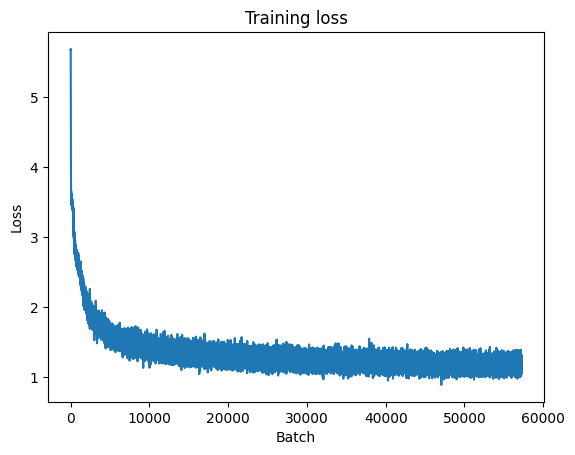

In [23]:
plt.plot(train_losses)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.savefig("loss_curve.png")

## Inference

In [24]:
# transformer.eval()
# def translate(eng_sentence):
#     transformer.eval()
#     with torch.no_grad():
#         eng_sentence = (eng_sentence,)
#         mr_sentence = ("",)
#         for word_counter in range(max_sequence_length):
#             encoder_self_attention_mask, \
#             decoder_self_attention_mask, \
#             decoder_cross_attention_mask = create_masks(eng_sentence, mr_sentence)
#             predictions = transformer(
#                 eng_sentence, mr_sentence,
#                 encoder_self_attention_mask.to(device),
#                 decoder_self_attention_mask.to(device),
#                 decoder_cross_attention_mask.to(device),
#                 enc_start_token=False, enc_end_token=False,
#                 dec_start_token=True, dec_end_token=False)
#             next_token_idx = torch.argmax(
#                 predictions[0][word_counter]).item()
#             next_token = index_to_marathi[next_token_idx]
#             if next_token == END_TOKEN:
#                 break
#             mr_sentence = (mr_sentence[0] + next_token,)
#     return mr_sentence[0]

In [25]:
def translate(eng_sentence):
    transformer.eval()
    with torch.no_grad():
        eng_sentence = (eng_sentence,)
        mr_sentence  = ("",)
        for word_counter in range(max_sequence_length):
            (encoder_self_attention_mask,
             decoder_self_attention_mask,
             decoder_cross_attention_mask) = create_masks(eng_sentence, mr_sentence)

            predictions = transformer(
                eng_sentence,
                mr_sentence,
                encoder_self_attention_mask.to(device),
                decoder_self_attention_mask.to(device),
                decoder_cross_attention_mask.to(device),
                enc_start_token=False,
                enc_end_token=False,
                dec_start_token=True,
                dec_end_token=False
            )
            # predictions shape: [1, seq_len, vocab_size]
            # position word_counter is the START token output at step 0,
            # so we want position word_counter (0-indexed from START=pos0,
            # first real char = pos1... but since mr_sentence starts empty,
            # the decoder sequence at step k is [START, c0...c(k-1)]
            # so the NEXT token logits are at predictions[0][word_counter]
            next_token_logits = predictions[0][word_counter]
            next_token_index  = torch.argmax(next_token_logits).item()
            next_token        = index_to_marathi[next_token_index]

            if next_token == END_TOKEN:
                break
            if next_token == PADDING_TOKEN:   # ← safety guard
                break

            mr_sentence = (mr_sentence[0] + next_token,)

    return mr_sentence[0]

In [26]:
translation = translate("what should we do when the day starts?")
print(translation)

त्यांच्या प्रश्नाचे उत्तर काय आहे?


In [27]:
translation = translate("how is this the truth?")
print(translation)

त्यांच्या काळात काय आहे?


In [28]:
translation = translate("the world is a large place with different people")
print(translation)

त्यांच्या पश्चात पत्नी आणि मुलगी आहेत.


In [29]:
translation = translate("my name is ajay")
print(translation)

त्यांच्या प्रतिक्रिया


In [30]:
translation = translate("i cannot stand this smell")
print(translation)

त्यांच्या प्रतिक्रिया करण्याची मागणी


In [31]:
translation = translate("noodles are the best")
print(translation)

प्रत्येक वेळी काय आहे?


In [32]:
translation = translate("why care about this?")
print(translation)

त्यांच्या काय आहे?


In [33]:
translation = translate("this is the best thing ever")
print(translation)

त्यांच्या प्रतिक्रिया करण्याची मागणी


In [34]:
translation = translate("i am here")
print(translation)

त्यांच्या प्रतिक्रिया


In [35]:
translation = translate("click this")
print(translation)

काय आहे ते काय आहेत?


In [36]:
translation = translate("where is the mall?")
print(translation)

त्यांच्या काय आहे?


In [37]:
translation = translate("what should we do?")
print(translation)

त्यांच्या काय आहे?


In [38]:
translation = translate("today, what should we do")
print(translation)

प्रत्येक वेळी काय आहे?


In [39]:
translation = translate("why did they activate?")
print(translation)

त्यांच्या काळात काय आहे?


In [40]:
translation = translate("why did they do this?")
print(translation)

त्यांच्या काळात काय आहे?


In [41]:
translation = translate("i am well.")
print(translation)

त्यांना माहिती देण्यात आली.


In [42]:
translation = translate("whats the word on the street?")
print(translation)

त्यांच्या काळात काय आहे?


In [45]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def evaluate_bleu(transformer, english_sentences, marathi_sentences, n_samples=500):
    transformer.eval()
    references, hypotheses = [], []
    with torch.no_grad():
        for eng, ref_mr in zip(english_sentences[:n_samples], marathi_sentences[:n_samples]):
            predicted = translate(eng)
            hypotheses.append(list(predicted))
            references.append([list(ref_mr)])
    smoother = SmoothingFunction().method1
    bleu = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    print(f"Corpus BLEU (char-level): {bleu:.4f}")
    return bleu, references, hypotheses  # ← return all three

# call site:
bleu, references, hypotheses = evaluate_bleu(transformer, english_sentences, marathi_sentences)

Corpus BLEU (char-level): 0.1358


In [46]:
from nltk.translate.bleu_score import corpus_bleu

for n in range(1, 5):
    weights = tuple([1/n]*n + [0]*(4-n))
    score = corpus_bleu(references, hypotheses, weights=weights,
                        smoothing_function=smoother)
    print(f"BLEU-{n}: {score:.4f}")

NameError: name 'smoother' is not defined

In [ ]:
# pip install sacrebleu
from sacrebleu.metrics import CHRF

chrf = CHRF()
predictions = [translate(eng) for eng in english_sentences[:500]]
score = chrf.corpus_score(predictions, [marathi_sentences[:500]])
print(f"chrF: {score}")  # higher is better, 0-100 scale

In [ ]:
test_cases = [
    "i am here",
    "where is the market?",
    "the sun rises in the east",
    "what should we do today?",
]

for eng in test_cases:
    pred = translate(eng)
    print(f"English  : {eng}")
    print(f"Predicted: {pred}")
    print()